#**Bài tập 1. Nhận diện khuôn mặt**

Import thư viện

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import os

Load datasets

In [ ]:
# Mount drive
drive.mount('/content/drive')

# Thêm tham số -o để tự động ghi đè, không bị treo hỏi y/n nữa
!unzip -o -q "/content/drive/MyDrive/60_ANH1.zip" -d "/content/dataset"

file_path = '/content/dataset/60 ẢNH/'
train_dir = file_path
validation_dir = file_path

Mounted at /content/drive


In [ ]:
img_width, img_height = 128, 128
batch_size = 64

Mở rộng bộ dữ liệu

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

Xây dựng mô hình

In [ ]:
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Sequential

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical'
)

model = Sequential([
    Input(shape=(img_width, img_height, 1)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(25, activation='softmax')
])

Found 970 images belonging to 25 classes.


Biên dịch

In [ ]:
model.compile(optimizer =  'adam',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │        12,825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,573,625 (36.52 MB)

 Trainable params: 9,573,625 (36.52 MB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện

In [ ]:
epochs = 50
history = model.fit(train_generator, epochs=epochs)

Đồ thị kết quả

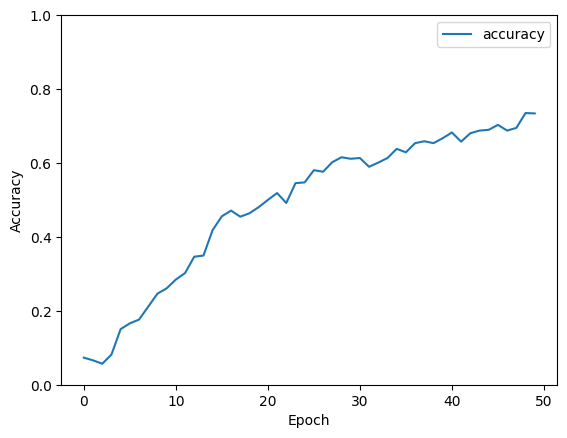

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0., 1])
plt.legend()
plt.show()

Lưu kết quả model

In [ ]:
path_keras = '/content/drive/MyDrive/mo_hinh_cnn_50_epochs.keras'
path_h5 = '/content/drive/MyDrive/mo_hinh_cnn_50_epochs.h5'

model.save(path_keras)
model.save(path_h5)

Sử dụng model đã lưu

In [ ]:
from keras.models import load_model
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

model_path = '/content/drive/MyDrive/mo_hinh_cnn_50_epochs.h5'

reloaded_model = load_model(model_path)

Test model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


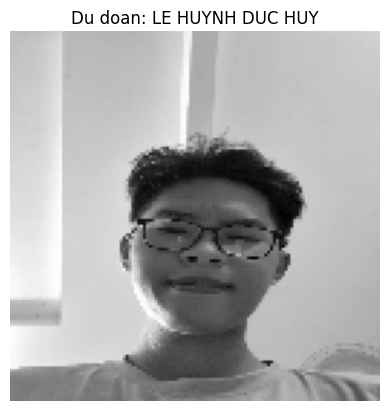

Kết quả nhận diện: LE HUYNH DUC HUY
Độ tự tin của mô hình: 42.55%


In [ ]:
image_path = '/content/Anh4.jpg'
img_width, img_height = 128, 128
img = load_img(image_path, target_size=(img_width, img_height), color_mode='grayscale')

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = reloaded_model.predict(img_array)
predicted_class_idx = np.argmax(predictions, axis=1)[0]
confidence = np.max(predictions) * 100

labels_map = {v: k for k, v in train_generator.class_indices.items()}
predicted_class_name = labels_map[predicted_class_idx]

plt.imshow(img, cmap='gray')
plt.title(f"Du doan: {predicted_class_name}")
plt.axis('off')
plt.show()

print(f"Kết quả nhận diện: {predicted_class_name}")
print(f"Độ tự tin của mô hình: {confidence:.2f}%")

In [ ]:
# In ra danh sách các lớp và số index tương ứng của nó
print(train_generator.class_indices)

{'DANG NGUYEN PHUONG NGHI': 0, 'HA PHUONG THAO': 1, 'HOANG BAO TRAN': 2, 'HOANG BUI TRA MY': 3, 'LE HUYNH DUC HUY': 4, 'LE MINH TRIET': 5, 'LE THI NHU QUYNH': 6, 'LE TRONG DAI': 7, 'MAI HO QUOC TUY': 8, 'NGUYEN BAO HAN': 9, 'NGUYEN DONG HAI': 10, 'NGUYEN HOANG BAO': 11, 'NGUYEN KHAC LUU VU': 12, 'NGUYEN NGOC KHANH UYEN': 13, 'NGUYEN NGOC KIM TUYET': 14, 'NGUYEN THI THANH HA': 15, 'NGUYEN TRONG MINH': 16, 'NHAN MANH TUAN': 17, 'PHAM DUC THANH CONG': 18, 'PHAM LY BAO LAM': 19, 'PHAM MAI PHUONG': 20, 'TRAN GIA HAN': 21, 'TRAN MINH HOANG': 22, 'TRAN NGOC THAO ANH': 23, 'TRAN THE DANG KHOA': 24}


Huấn luyện lần 2

In [ ]:
from keras.models import load_model
from tensorflow.keras.optimizers import Adam

model_path = '/content/drive/MyDrive/mo_hinh_cnn_50_epochs.h5'
model = load_model(model_path)
print("🎉 Đã nạp thành công mô hình cũ để chuẩn bị train tiếp!")

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

epochs_them = 30
history_them = model.fit(train_generator, epochs=epochs_them)

🎉 Đã nạp thành công mô hình cũ để chuẩn bị train tiếp!
Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.7567 - loss: 0.7720
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 101s 6s/step - accuracy: 0.7722 - loss: 0.7269
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 95s 6s/step - accuracy: 0.7732 - loss: 0.7372
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 87s 6s/step - accuracy: 0.7608 - loss: 0.7621
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - accuracy: 0.7753 - loss: 0.7310
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 95s 6s/step - accuracy: 0.7835 - loss: 0.6914
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 89s 5s/step - accuracy: 0.7876 - loss: 0.6833
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 96s 6s/step - accuracy: 0.7691 - loss: 0.7669
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 90s 5s/step - accuracy: 0.7691 - loss: 0.7234
Epoch 10/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 86s 5s/step - accuracy: 0.7753 - loss: 0.6598
Epoch 11/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 87s 5s/step - accuracy: 0.7866 - loss: 0.7193
Epoch 12/30
16/16

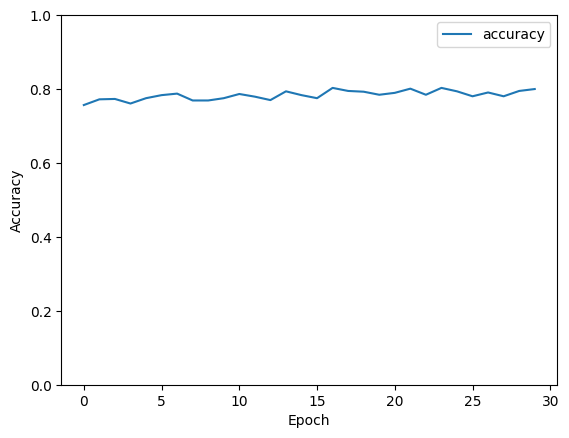

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history_them.history['accuracy'], label='accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0., 1])
plt.legend()
plt.show()

Lưu kết quả mới

In [ ]:
path_80_keras = '/content/drive/MyDrive/mo_hinh_cnn_80_epochs.keras'
path_80_h5 = '/content/drive/MyDrive/mo_hinh_cnn_80_epochs.h5'

model.save(path_80_keras)
model.save(path_80_h5)

print(f"File 1: {path_80_keras}")
print(f"File 2: {path_80_h5}")

File 1: /content/drive/MyDrive/mo_hinh_cnn_80_epochs.keras
File 2: /content/drive/MyDrive/mo_hinh_cnn_80_epochs.h5


Test lần 2


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step


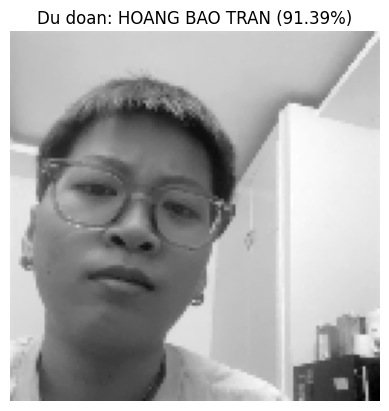

Kết quả nhận diện khuôn mặt: HOANG BAO TRAN
Độ tự tin (Confidence): 91.39%


In [ ]:
from keras.models import load_model
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')
model_path = '/content/drive/MyDrive/mo_hinh_cnn_80_epochs.h5'
image_path = '/content/Anh7.jpg'
reloaded_model = load_model(model_path)

img_width, img_height = 128, 128
img = load_img(image_path, target_size=(img_width, img_height), color_mode='grayscale')

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = reloaded_model.predict(img_array)
predicted_class_idx = np.argmax(predictions, axis=1)[0]
confidence = np.max(predictions) * 100

labels_map = {v: k for k, v in train_generator.class_indices.items()}
predicted_class_name = labels_map[predicted_class_idx]

plt.imshow(img, cmap='gray')
plt.title(f"Du doan: {predicted_class_name} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"Kết quả nhận diện khuôn mặt: {predicted_class_name}")
print(f"Độ tự tin (Confidence): {confidence:.2f}%")

In [ ]:
print(train_generator.class_indices)

{'DANG NGUYEN PHUONG NGHI': 0, 'HA PHUONG THAO': 1, 'HOANG BAO TRAN': 2, 'HOANG BUI TRA MY': 3, 'LE HUYNH DUC HUY': 4, 'LE MINH TRIET': 5, 'LE THI NHU QUYNH': 6, 'LE TRONG DAI': 7, 'MAI HO QUOC TUY': 8, 'NGUYEN BAO HAN': 9, 'NGUYEN DONG HAI': 10, 'NGUYEN HOANG BAO': 11, 'NGUYEN KHAC LUU VU': 12, 'NGUYEN NGOC KHANH UYEN': 13, 'NGUYEN NGOC KIM TUYET': 14, 'NGUYEN THI THANH HA': 15, 'NGUYEN TRONG MINH': 16, 'NHAN MANH TUAN': 17, 'PHAM DUC THANH CONG': 18, 'PHAM LY BAO LAM': 19, 'PHAM MAI PHUONG': 20, 'TRAN GIA HAN': 21, 'TRAN MINH HOANG': 22, 'TRAN NGOC THAO ANH': 23, 'TRAN THE DANG KHOA': 24}
